# 📈 Sentiment EDA: Polarity & Engagement Index
**Dataset:** Bundesliga 24/25 - Enriched with BERTimbau Sentiment

Este notebook analisa as emoções capturadas no chat, calculando a polaridade das partidas e o índice de engajamento ponderado por sentimento.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# 1. Carregar dados enriquecidos
df = pd.read_parquet('../data/processed/consolidated/bundesliga_chat_with_sentiment.parquet')
with open('../config/video_info.json', 'r') as f:
    v_info = {v['video_id']: v['title'] for v in json.load(f)}

df['min_lin'] = (df['timestamp_jogo_segundos'] // 60).astype(int)
print(f"Dataset carregado: {len(df):,} mensagens.")

Dataset carregado: 246,918 mensagens.


## 2. Cálculo de Métricas Avançadas

### Polaridade (Polarity)
Mede o balanço entre positivo e negativo. 
$$Polarity = \frac{Positivos - Negativos}{Total}$$

### Engagement-Weighted Sentiment Index (EWSI)
Como não temos 'likes' no chat, usamos o **Volume de Mensagens por Minuto** como peso de engajamento. Momentos de alto volume e alta polaridade geram os maiores picos de índice.
$$EWSI = Polarity \times \log(Volume + 1)$$

In [2]:
def calculate_metrics(group):
    counts = group['sentiment_label'].value_counts()
    pos = counts.get('Positivo', 0)
    neg = counts.get('Negativo', 0)
    total = len(group)
    
    polarity = (pos - neg) / total if total > 0 else 0
    ewsi = polarity * np.log1p(total)
    
    return pd.Series({
        'volume': total,
        'polarity': polarity,
        'ewsi': ewsi
    })

# Agrupar por Video e Minuto para análise temporal
stats_minuto = df.groupby(['video_id', 'min_lin']).apply(calculate_metrics, include_groups=False).reset_index()

## 3. O 'Pulso' da Temporada
Visualização da Polaridade Média minuto a minuto em todos os jogos.

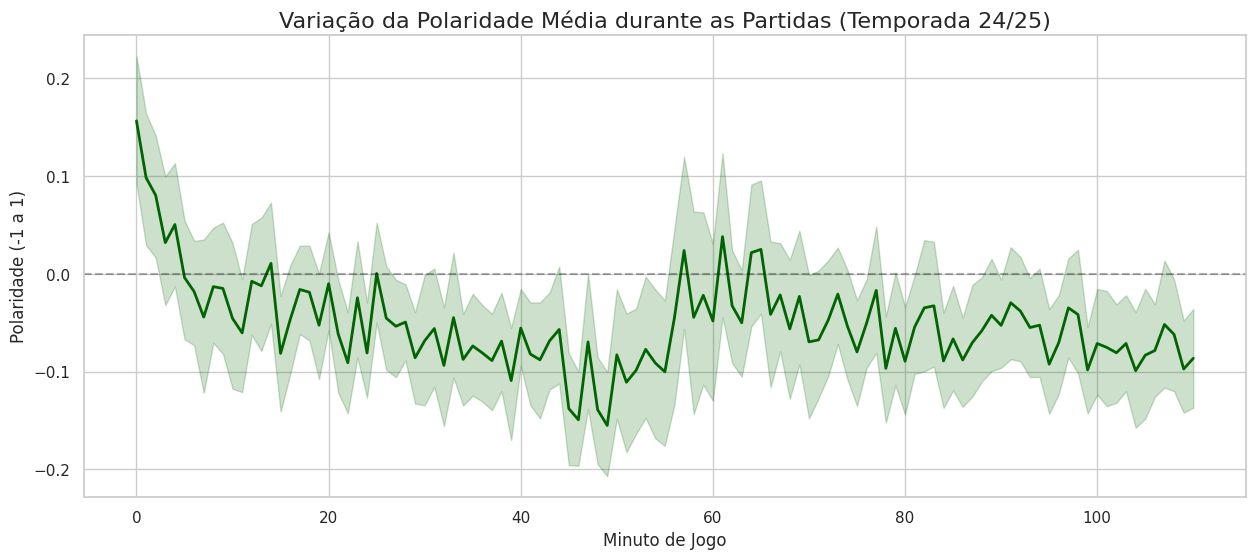

In [3]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=stats_minuto[stats_minuto['min_lin'].between(0, 110)], 
             x='min_lin', y='polarity', color='darkgreen', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Variação da Polaridade Média durante as Partidas (Temporada 24/25)', fontsize=16)
plt.xlabel('Minuto de Jogo')
plt.ylabel('Polaridade (-1 a 1)')
plt.show()

## 4. Engagement-Weighted Sentiment Index (EWSI)
Este gráfico destaca os momentos de 'Hype Positivo' vs 'Crise/Reclamação' ponderados pelo volume de mensagens.

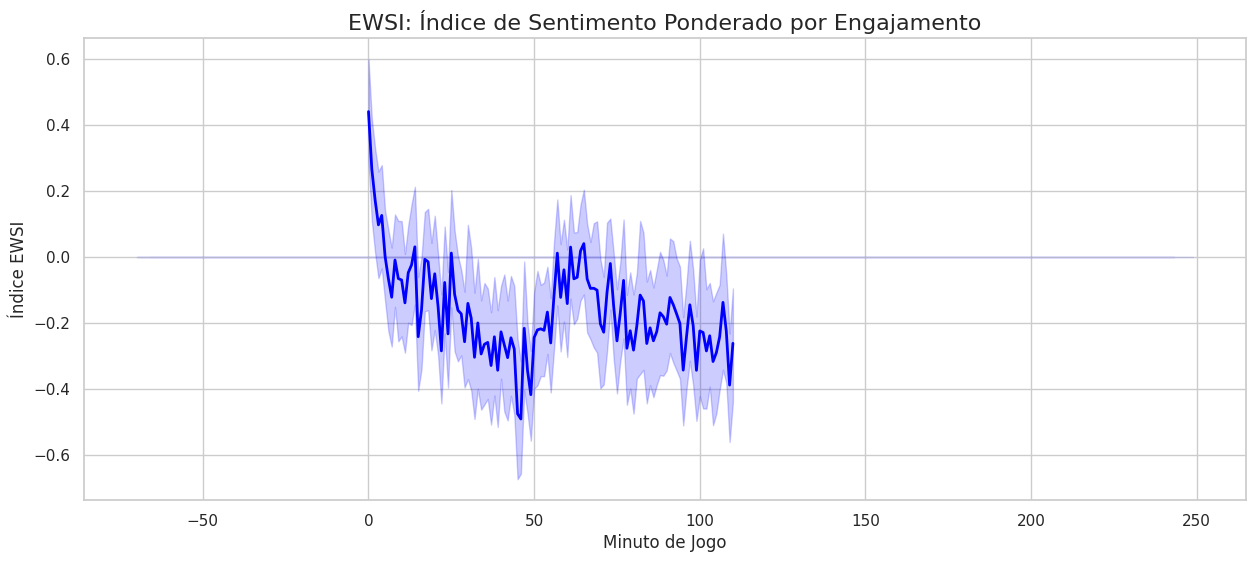

In [4]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=stats_minuto[stats_minuto['min_lin'].between(0, 110)], 
             x='min_lin', y='ewsi', color='blue', linewidth=2)
plt.fill_between(stats_minuto['min_lin'].unique(), 0, color='blue', alpha=0.1)
plt.title('EWSI: Índice de Sentimento Ponderado por Engajamento', fontsize=16)
plt.xlabel('Minuto de Jogo')
plt.ylabel('Índice EWSI')
plt.show()

## 5. Ranking de 'Felicidade' por Time
Quais torcidas foram mais positivas ao longo da temporada?

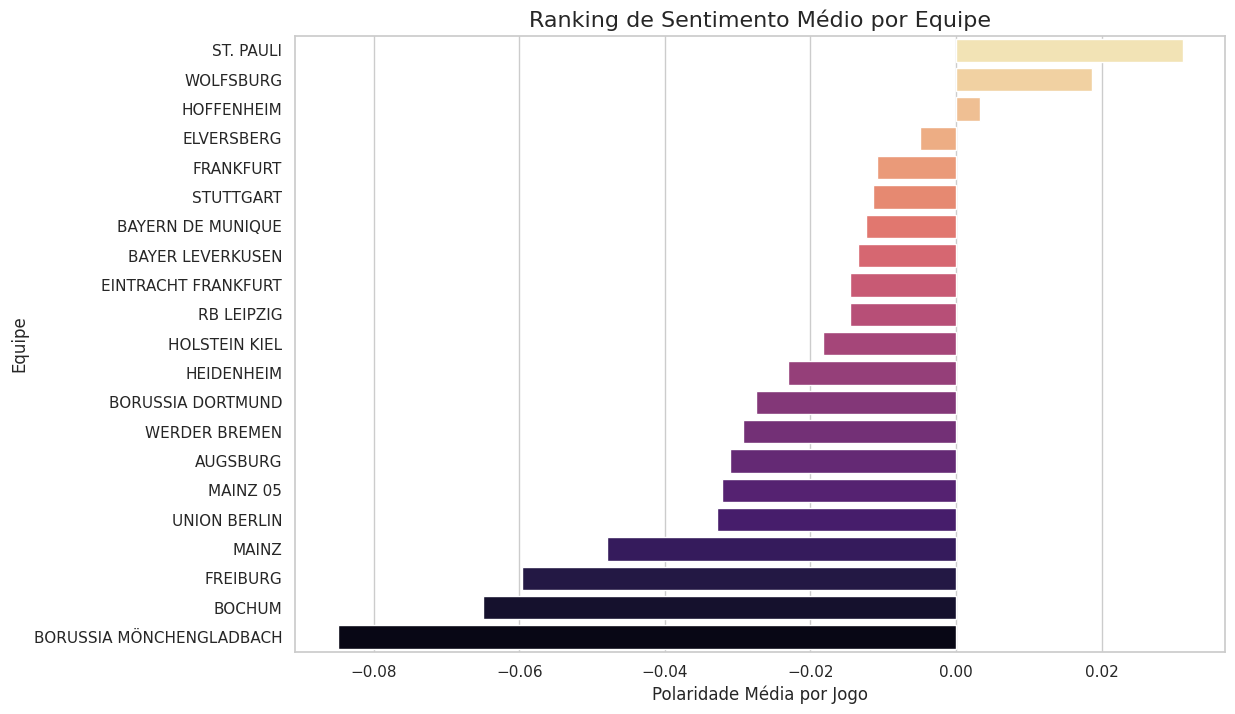

In [13]:
import re
def extract_teams(title):
    match = re.search(r'JOGO COMPLETO: (.*?) \|', title)
    if match: return [t.strip() for t in re.split(r' [xX] ', match.group(1))]
    return []

team_sentiment = []
for v_id, title in v_info.items():
    teams = extract_teams(title)
    avg_pol = stats_minuto[stats_minuto['video_id'] == v_id]['polarity'].mean()
    for team in teams:
        team_sentiment.append({'team': team, 'polarity': avg_pol})

team_rank = pd.DataFrame(team_sentiment).groupby('team')['polarity'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=team_rank.values, y=team_rank.index, hue=team_rank.index, palette='magma_r', legend=False)
plt.title('Ranking de Sentimento Médio por Equipe', fontsize=16)
plt.xlabel('Polaridade Média por Jogo')
plt.ylabel('Equipe')
plt.show()